# XGBoost导高预测模型残差分析：XGBRegressor Regression
## 
### 2025.02.20 sunyu 

In [1]:
#导入库
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from lightgbm.sklearn import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor  #GBDT
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
from xgboost import XGBRegressor  #XGBoosting

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from hyperopt import fmin, tpe, hp, anneal, Trials
# Skopt functions   
from skopt import BayesSearchCV
#from skopt.callbacks import DeadlineStopper, DeltaYStopper
#from skopt.space import Real, Categorical, Integer
#No module named 'skopt':  pip install scikit-optimize

from yellowbrick.regressor import PredictionError,ResidualsPlot 
# ModuleNotFoundError: No module named 'yellowbrick'
# pip install yellowbrick

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

import seaborn as sns
import matplotlib.pyplot as plt

import math
from scipy.stats import randint
import timeit
import os
import psutil
import missingno as msno

In [3]:
import sklearn
print(sklearn.__version__)

1.5.1


In [2]:
# 读取CSV文件
data = pd.read_csv('20241128_sunyu.csv',encoding='gbk',header=0)

In [ ]:
#data.columns
data

In [3]:
# 获取特征和目标变量
X = data.drop('导高', axis=1) #'daogao'
y = data['导高']

In [4]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
num_folds=2
random_state=3
kf = KFold(n_splits=num_folds) #, random_state=3
n_iter = 50

# XGBoost Regressor and GridSearch

In [6]:
#'learning_rate': np.logspace(-4, 0, 5),
#'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
#'n_estimators': np.linspace(30,150,120, dtype = int),
#此程序运行占内存10.5234375mB
#Running time:141.36394s
#Best MSE 734.860 params {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 138}

#时间占用 s
start=timeit.default_timer()
#内存占用 mb
info_start = psutil.Process(os.getpid()).memory_info().rss/1024/1024
# MemoryError 当参数过多，就出现内存错误
param_grid={'learning_rate': np.logspace(-4, 0, 5),
            'max_depth':  np.linspace(1,10,10,dtype = int),#最大深度的选择, 从1到20，步长为1
            'n_estimators': np.linspace(30,150,120, dtype = int),
            #'subsample': np.linspace(0.1, 1.0, 10),  #Best MSE 780.007 params {'learning_rate': 0.1, 'n_estimators': 109, 'subsample': 0.4}
            #'min_child_weight': [1,3,5],
            #'colsample_bytree':np.linspace(0.1, 1.0, 10), # subsample ratio of columns by tree
            #'max_delta_step': np.linspace(0.1, 1.0, 10),
            #'gamma':np.linspace(0,100,101, dtype = int),
            #'reg_alpha': np.logspace(-4, 1, 5), # L1 regularization
            #'reg_lambda': np.linspace(0,50,51)# L2 regularization    MSE 875.392
           }
xgb = XGBRegressor(random_state=3)
gs=GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', #fit_params=None, 
                n_jobs=-1, cv=kf, verbose=1)
gs.fit(X_train, y_train)
gs_test_score=mean_squared_error(y_test, gs.predict(X_test))

end=timeit.default_timer()
info_end = psutil.Process(os.getpid()).memory_info().rss/1024/1024

print('此程序运行占内存'+str(info_end-info_start)+'mB')
print('Running time:%.5fs'%(end-start))
print("Best MSE {:.3f} params {}".format(-gs.best_score_, gs.best_params_))

#Best MSE 976.168 params {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 76}

Fitting 2 folds for each of 6000 candidates, totalling 12000 fits
此程序运行占内存12.8828125mB
Running time:141.04085s
Best MSE 1027.816 params {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 53}


# RandomsizeSearch

In [7]:

param_grid_rand={
    'learning_rate': np.logspace(-4, 0, 100),
    'max_depth':  randint(1,10),
    'n_estimators': randint(10,150),
    'random_state': [3]
}

xgb_rs=XGBRegressor()
rs = RandomizedSearchCV(
    xgb_rs,
    param_grid_rand,
    n_iter=n_iter,
    scoring="neg_mean_squared_error",
    #fit_params=None,
    n_jobs=-1,
    cv=kf,
    verbose=1,
    random_state=random_state,
)

rs.fit(X_train, y_train)
y_pred = rs.predict(X_test)
rs_test_score = mean_squared_error(y_test, y_pred)

print("Best MSE {:.3f} params {}".format(-rs.best_score_, rs.best_params_))

Fitting 2 folds for each of 50 candidates, totalling 100 fits
Best MSE 1115.699 params {'learning_rate': 0.3274549162877732, 'max_depth': 4, 'n_estimators': 72, 'random_state': 3}


In [8]:
xgb_best = XGBRegressor(random_state=3, n_estimators=76,max_depth=3,learning_rate=0.1,
                    #subsample=best['subsample'],#colsample_bytree=best['colsample_bytree'], max_delta_step=best['max_delta_step'], 
                   #min_child_weight=best['min_child_weight'],#, max_features=best['max_features'],
                   #gamma=best['gamma'],  reg_alpha=best['reg_alpha'], reg_lambda=best['reg_lambda']
)

In [9]:
xgb_best.fit(X_train, y_train)

y_pred = xgb_best.predict(X_test)
rs_test_score = mean_squared_error(y_test, y_pred)

print("Best MSE {:.3f} ".format(-rs.best_score_))

Best MSE 1115.699 


In [10]:
# Calculating the error
mse = round(mean_squared_error(y_test, y_pred), 2)
rmse = round(math.sqrt(mean_squared_error(y_test, y_pred)), 2)
map = round(mean_absolute_percentage_error(y_test, y_pred), 2)
r2 = round(r2_score(y_test, y_pred), 7)

print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAP: {map}')
print(f'R2: {r2}')

MSE: 603.43
RMSE: 24.56
MAP: 0.23
R2: 0.7394429


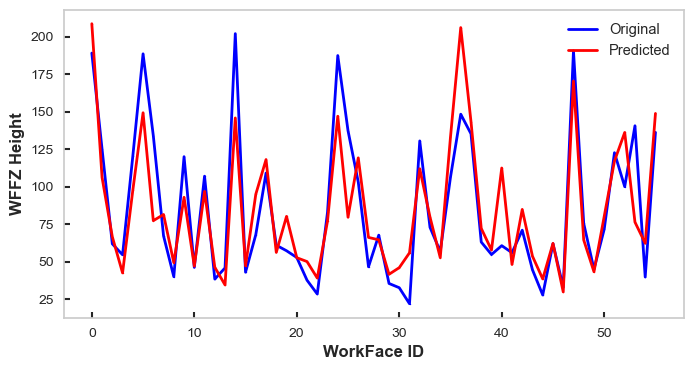

In [11]:
# 4. 创建一个图形窗口，包含多个子图
fig, ax = plt.subplots(1, 1, figsize=(8, 4))  # 3行1列的子图   #plt.figure(figsize=(18/2.54, 5/2.54),dpi=400)

# 网格优化
ax.plot(range(y_test.shape[0]),y_test, label='Original', color='blue', linewidth=2, marker='o', markersize=1)
ax.plot(range(y_test.shape[0]),y_pred, label='Predicted', color='red', linewidth=2, marker='o', markersize=1)
# 设置标题和标签
ax.set_xlabel('WorkFace ID', fontsize=12, weight='bold')
ax.set_ylabel(r'WFFZ Height', fontsize=12, weight='bold')
ax.legend(fontsize=10.5,loc='upper right')
ax.tick_params(axis='both', which='both', direction='in', length=4, width=1.5)
ax.grid(False) #, which='both', linestyle='--', linewidth=0.5
'''
plt.plot(y_test, color='b', label='Original')
plt.plot(y_pred, color='r', label='Predicted')
plt.title('Decision Tree Regression model')
#plt.xticks(np.arange(0, round(X_test.shape[0] * 0.3), t), X_test)
plt.xlabel('ID')
plt.ylabel('Height')
plt.legend(loc='upper right')
plt.show()
#ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# 随机优化
ax[1].plot(scores_df.index,scores_df["Random Search"] , label='Random Search', color='red', linewidth=2, marker='o', markersize=2)
# 设置标题和标签
# 设置标题和标签
ax[1].set_xlabel('number_of_iterations', fontsize=12, weight='bold')
ax[1].set_ylabel(r'best_cumulative_score', fontsize=12, weight='bold')
ax[1].legend(fontsize=12)
ax[1].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)

# 贝叶斯优化
ax[2].plot(scores_df.index,scores_df["TPE"], label='TPE', color='green', linewidth=2, marker='o', markersize=2)
ax[2].plot(scores_df.index,scores_df["Annealing"], label='Annealing', color='orange', linewidth=2, marker='o', markersize=2)
# 设置标题和标签
# 设置标题和标签
ax[2].set_xlabel('number_of_iterations', fontsize=12, weight='bold')
ax[2].set_ylabel(r'best_cumulative_score', fontsize=12, weight='bold')
ax[2].legend(fontsize=12)
ax[2].tick_params(axis='both', which='both', direction='in', length=4, width=1.5)

# 设置图表的总体标题
#fig.suptitle('XGBoost Regressor: MSE vs Hyperparameters', fontsize=8, weight='bold')

# 调整布局，防止标签被遮挡
plt.tight_layout()
plt.subplots_adjust(wspace=0.2)  # 调整整体标题的位置
#plt.subplots_adjust(left=0.125,bottom=-0.51,right=1.3,top=0.88,hspace=1.2)
'''
# 保存为适合出版的图片格式
#plt.savefig('XGBoost_regression_WFFZ0220.png', dpi=400)
plt.show()

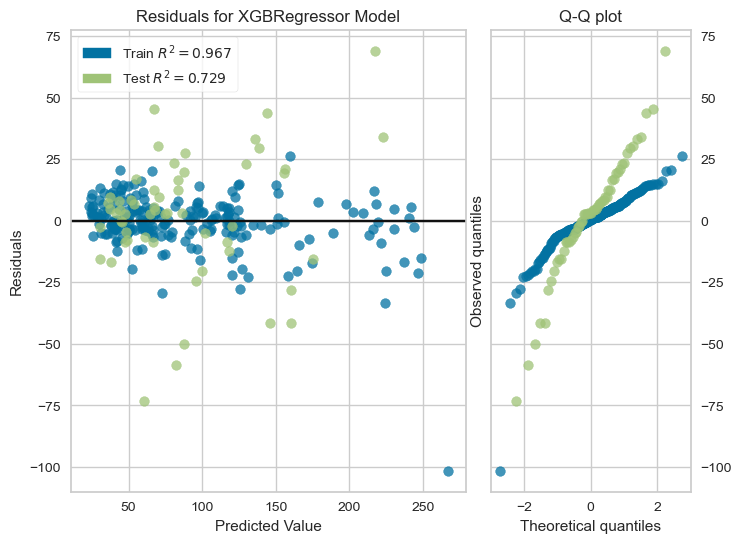

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

xgb4 = XGBRegressor(learning_rate=0.067,max_depth=5, n_estimators=95,random_state=3,reg_alpha=0.6,reg_lambda=9)

visualizer = ResidualsPlot(xgb4, ax=ax,hist=False, qqplot=True,train_color='b',test_color='g')
#model = Ridge()
#visualizer = ResidualsPlot(model)
visualizer.fit(X_train,y_train)
visualizer.score(X_test,y_test)
g = visualizer.poof(outpath="Residuals_Plot0.849_20250220.png") # VECTOR .pdf .eps .svg, RASTER .png .jpg .tif
#plt.savefig("Residuals_Plot0.755_20250219.jpg",dpi=400)

E:\anaconda\Lib\site-packages\sklearn\linear_model\_ridge.py:2341: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\deprecation.py:102: FutureWarning: Attribute `cv_values_` is deprecated in version 1.5 and will be removed in 1.7. Use `cv_results_` instead.
  warnings.warn(msg, category=FutureWarning)


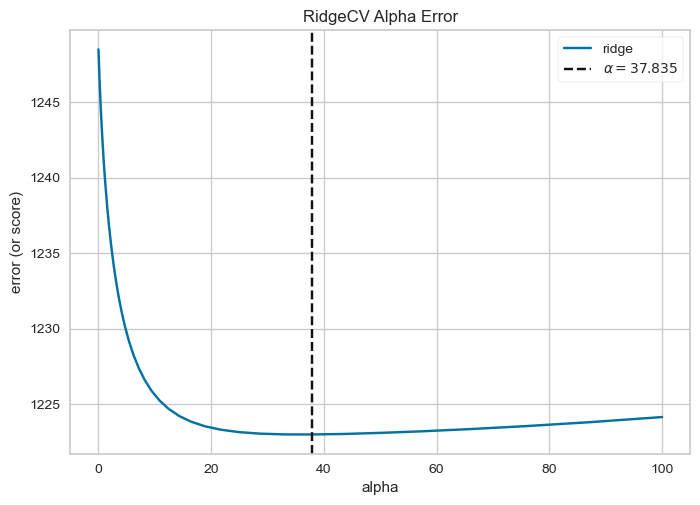

<Axes: title={'center': 'RidgeCV Alpha Error'}, xlabel='alpha', ylabel='error (or score)'>

In [13]:
from sklearn.linear_model import RidgeCV
from yellowbrick.regressor import AlphaSelection

alphas = np.logspace(-10, 2, 200)
visualizer = AlphaSelection(RidgeCV(alphas=alphas))
visualizer.fit(X, y)
visualizer.poof()

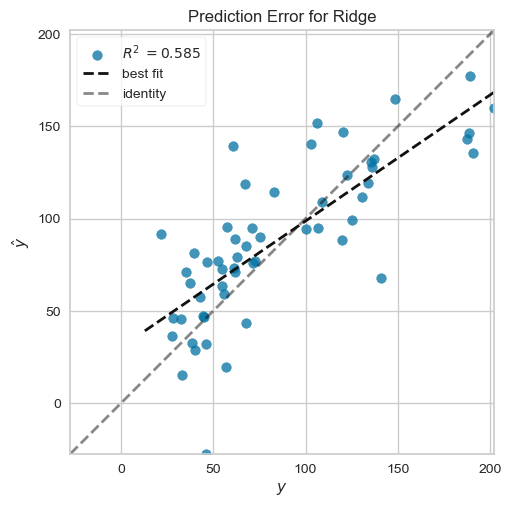

<Axes: title={'center': 'Prediction Error for Ridge'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [14]:
visualizer = PredictionError(Ridge(alpha=37.835))
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.poof()